In [ ]:
!pip install bertopic
!pip install sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.0/153.0 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 35.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 31.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 39.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 89.4 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu

In [ ]:
import pandas as pd
import numpy as np
from bertopic import BERTopic
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer
from collections import defaultdict
from sentence_transformers import SentenceTransformer

In [ ]:
# gunakan embedding model dari IndoBERT
embedding_model = SentenceTransformer("indobenchmark/indobert-base-p1")

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [ ]:
# import data
df = pd.read_csv('/content/result_2.csv')
df

# filter
df_filtered = df[df['title'] == 'Rumah Sakit Umum Pusat Surakarta']
display(df_filtered)

,title,stars,text,bin_pelayanan,bin_fasilitas,predicted_labels_1,labels,prob_layanan,prob_fasilitas
7148,Rumah Sakit Umum Pusat Surakarta,5,rencana mau kontrol kehamilan di usia 34 mingg...,1,0,['pelayanan'],positive,0.994412,0.004023
7149,Rumah Sakit Umum Pusat Surakarta,5,penanganan perawatan dan pelayanan selalu prima,1,0,['pelayanan'],positive,0.997122,0.004736
7150,Rumah Sakit Umum Pusat Surakarta,5,trimkasih banyak tht mantul,1,1,"['pelayanan', 'fasilitas']",positive,0.974799,0.658542
7151,Rumah Sakit Umum Pusat Surakarta,1,kurang puas dengan pelayanan rumah sakit ini,1,0,['pelayanan'],negative,0.996783,0.004242
7152,Rumah Sakit Umum Pusat Surakarta,2,pelayanan yg dirawat inap gak ramah,1,0,['pelayanan'],negative,0.997592,0.005368
...,...,...,...,...,...,...,...,...,...
7634,Rumah Sakit Umum Pusat Surakarta,4,lama banget pelayanan untuk pasien baru ibu ny...,1,0,['pelayanan'],negative,0.998652,0.013547
7635,Rumah Sakit Umum Pusat Surakarta,4,hospital yg sangat rapi pelayanan bagus,1,1,"['pelayanan', 'fasilitas']",positive,0.998214,0.969155
7636,Rumah Sakit Umum Pusat Surakarta,4,khusus paru,0,0,[],positive,0.154345,0.233327
7637,Rumah Sakit Umum Pusat Surakarta,5,rs paru,0,0,[],neutral,0.122932,0.100288


In [ ]:
# menghapus stopwords
import re

# daftar
stopwords = ['saya', 'yg', 'dan', 'yang', 'di', 'tidak', 'juga', 'utk', 'itu',
             'untuk', 'juga', 'jg', 'nya', 'tapi', 'tp', 'ga', 'gak', 'ngga', 'nggak', 'sy', 'lagi',
             'lg', 'dengan', 'dgn', 'dg', 'ini', 'kami', 'apa', 'ada', 'ke', 'ya', 'dong', 'sgt', 'bgt',
             'karena', 'krn', 'sebagai', 'sbg', 'dari', 'malah']

# function
def remove_stopwords(text):
    if isinstance(text, str):  # make sure string
        pattern = r'\b(?:' + '|'.join(stopwords) + r')\b'
        return re.sub(pattern, '', text, flags=re.IGNORECASE).strip()
    return text


df_filtered['text'] = df_filtered['text'].apply(remove_stopwords)

# Kategori

In [ ]:
# insialisasi model untuk dua kategori
layanan_model = BERTopic(embedding_model=embedding_model, min_topic_size=10, nr_topics=5)
fasilitas_model = BERTopic(embedding_model=embedding_model, min_topic_size=10, nr_topics=5)

In [ ]:
# Fungsi untuk memisahkan ulasan berdasarkan probabilitas kategori
def assign_reviews_by_category(data, threshold=0.5):
    layanan_reviews = []
    fasilitas_reviews = []
    layanan_indices = []
    fasilitas_indices = []
    for idx, row in data.iterrows():
        if row['prob_layanan'] >= threshold:
            layanan_reviews.append(row['text'])
            layanan_indices.append(idx)
        if row['prob_fasilitas'] >= threshold:
            fasilitas_reviews.append(row['text'])
            fasilitas_indices.append(idx)
    return layanan_reviews, fasilitas_reviews, layanan_indices, fasilitas_indices

# Memisahkan ulasan (ulasan dengan prob 0.99 masuk ke kedua kategori)
layanan_reviews, fasilitas_reviews, layanan_indices, fasilitas_indices = assign_reviews_by_category(df_filtered, threshold=0.5)

In [ ]:
# Pemodelan topik untuk kategori layanan
if layanan_reviews:
    topics_layanan, probs_layanan = layanan_model.fit_transform(layanan_reviews)
else:
    topics_layanan, probs_layanan = [], []

In [ ]:
# Pemodelan topik untuk kategori fasilitas
if fasilitas_reviews:
    topics_fasilitas, probs_fasilitas = fasilitas_model.fit_transform(fasilitas_reviews)
else:
    topics_fasilitas, probs_fasilitas = [], []

In [ ]:
# layanan_model.update_topics(layanan_reviews, top_n_words=10)  # Batasi ke 10 kata
# fasilitas_model.update_topics(fasilitas_reviews, top_n_words=10)  # Batasi ke 10 kata

## Hasil topic modelling

In [ ]:
# melihat total topic layanan
print(len(layanan_model.get_topics()))

# melihat total topic fasilitas
print(len(fasilitas_model.get_topics()))

5
2


In [ ]:
layanan_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,48,-1_pelayanan_baik_ramah_makin,"[pelayanan, baik, ramah, makin, bagus, sangat,...",[rumah sakit bersih pelayanannya super duper r...
1,0,276,0_pelayanan_dokter_rsup_sangat,"[pelayanan, dokter, rsup, sangat, pasien, rama...",[terimakasih dokter suster serta lainnya be...
2,1,59,1_ramah_bersih_pelayanan_baik,"[ramah, bersih, pelayanan, baik, rapi, sangat,...",[pelayanan sangat bagus perawatnya ramah ramah...
3,2,56,2_pelayanan_bagus_pelayanannya_ramah,"[pelayanan, bagus, pelayanannya, ramah, sangat...","[pelayanan sangat bagus, bagus pelayanan, pel..."
4,3,20,3_ramah_pelayanan_cepat_bagus,"[ramah, pelayanan, cepat, bagus, sangat, sana,...","[pelayanan bagus petugas ramah, pelayanan bagu..."


In [ ]:
fasilitas_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,0,25,0_bagus_mantap_makin_gila,"[bagus, mantap, makin, gila, jaya, lebih, kura...",[Biarkan memeriksa teman 16 menit lebih 3 j...
1,1,148,1_ramah_pelayanan_bersih_sangat,"[ramah, pelayanan, bersih, sangat, baik, anak,...",[pelayanan rsup baik nyaman ramah area bersih...


## Frekuensi sentimen dari setiap topik

In [ ]:
import numpy as np
import pandas as pd

# === Analisis Topik & Sentimen untuk Layanan ===
# Pastikan indeks valid
layanan_indices_valid = np.intersect1d(layanan_indices, df_filtered.index)

df_layanan = df_filtered.loc[layanan_indices_valid].copy()
df_layanan["topic"] = topics_layanan[:len(df_layanan)]  # pastikan panjang sama

df_layanan = df_layanan[df_layanan['topic'] != -1]
topic_sentiment_layanan = pd.crosstab(df_layanan['topic'], df_layanan['labels'])
emotion_dist_layanan = pd.crosstab(df_layanan['topic'], df_layanan['labels'], normalize='index')

print("=== Distribusi Sentimen per Topik (Layanan) ===")
print(topic_sentiment_layanan)
print("\n=== Proporsi Sentimen per Topik (Layanan) ===")
print(emotion_dist_layanan)


# === Analisis Topik & Sentimen untuk Fasilitas ===
# Pastikan indeks valid
fasilitas_indices_valid = np.intersect1d(fasilitas_indices, df_filtered.index)

df_fasilitas = df_filtered.loc[fasilitas_indices_valid].copy()
df_fasilitas["topic"] = topics_fasilitas[:len(df_fasilitas)]  # pastikan panjang sama

df_fasilitas = df_fasilitas[df_fasilitas['topic'] != -1]
topic_sentiment_fasilitas = pd.crosstab(df_fasilitas['topic'], df_fasilitas['labels'])
emotion_dist_fasilitas = pd.crosstab(df_fasilitas['topic'], df_fasilitas['labels'], normalize='index')

print("\n=== Distribusi Sentimen per Topik (Fasilitas) ===")
print(topic_sentiment_fasilitas)
print("\n=== Proporsi Sentimen per Topik (Fasilitas) ===")
print(emotion_dist_fasilitas)


=== Distribusi Sentimen per Topik (Layanan) ===
labels  negative  neutral  positive
topic                              
0             92       28       156
1              2        1        56
2             11        3        42
3              1        0        19

=== Proporsi Sentimen per Topik (Layanan) ===
labels  negative   neutral  positive
topic                               
0       0.333333  0.101449  0.565217
1       0.033898  0.016949  0.949153
2       0.196429  0.053571  0.750000
3       0.050000  0.000000  0.950000

=== Distribusi Sentimen per Topik (Fasilitas) ===
labels  negative  neutral  positive
topic                              
0              7        0        18
1             16        9       123

=== Proporsi Sentimen per Topik (Fasilitas) ===
labels  negative   neutral  positive
topic                               
0       0.280000  0.000000  0.720000
1       0.108108  0.060811  0.831081


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

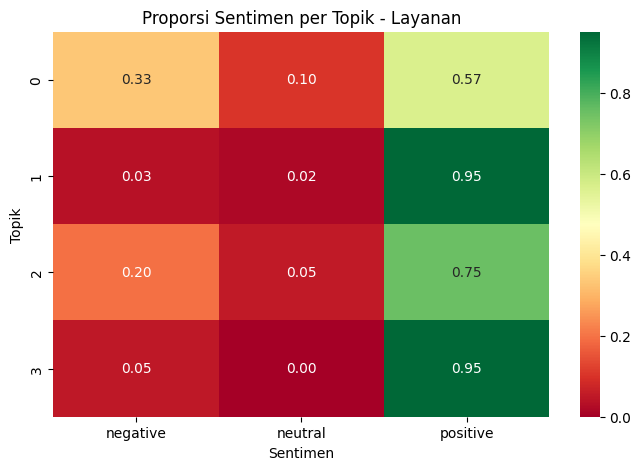

In [ ]:
# Heatmap proporsi (Layanan)
plt.figure(figsize=(8, 5))
sns.heatmap(emotion_dist_layanan, annot=True, fmt=".2f", cmap="RdYlGn")
plt.title("Proporsi Sentimen per Topik - Layanan")
plt.ylabel("Topik")
plt.xlabel("Sentimen")
plt.show()

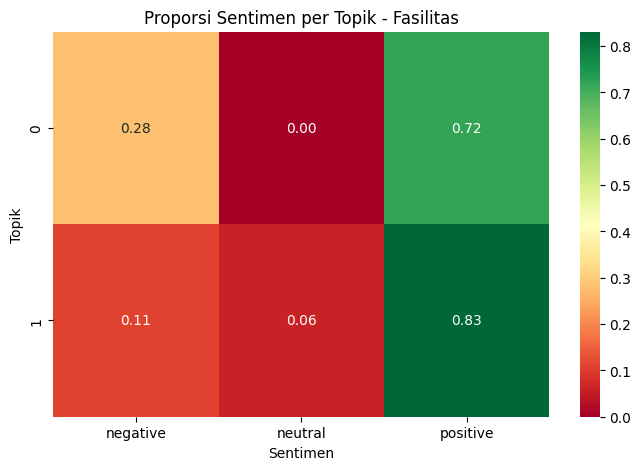

In [ ]:
# Heatmap proporsi (Layanan)
plt.figure(figsize=(8, 5))
sns.heatmap(emotion_dist_fasilitas, annot=True, fmt=".2f", cmap="RdYlGn")
plt.title("Proporsi Sentimen per Topik - Fasilitas")
plt.ylabel("Topik")
plt.xlabel("Sentimen")
plt.show()

In [ ]:
# Fungsi untuk menampilkan kata kunci tiap topik
def tampilkan_topik(model, kategori):
    topics = model.get_topics()
    print(f"=== Topik untuk kategori {kategori} ===")
    for topic_id, topic_info in topics.items():
        print(f"Topic {topic_id}:")
        print(f"Representasi: {topic_info}")
        print("-" * 50)
    print("\n")

# Panggil untuk layanan dan fasilitas
tampilkan_topik(layanan_model, "Layanan")
tampilkan_topik(fasilitas_model, "Fasilitas")

=== Topik untuk kategori Layanan ===
Topic -1:
Representasi: [('pelayanan', np.float64(0.09934071441130851)), ('baik', np.float64(0.09324371249903414)), ('ramah', np.float64(0.07527538460281098)), ('makin', np.float64(0.06485284119033506)), ('bagus', np.float64(0.05928277937811551)), ('sangat', np.float64(0.05751799277995193)), ('bagian', np.float64(0.053724631406993274)), ('semua', np.float64(0.04664842128747018)), ('semoga', np.float64(0.04638531933317482)), ('rumah', np.float64(0.03887368440622515))]
--------------------------------------------------
Topic 0:
Representasi: [('pelayanan', np.float64(0.03942768015276348)), ('dokter', np.float64(0.03916349077057639)), ('rsup', np.float64(0.03811422424794883)), ('sangat', np.float64(0.0361078477852249)), ('pasien', np.float64(0.0331546779271114)), ('ramah', np.float64(0.03221954791699631)), ('baik', np.float64(0.03130226985415843)), ('anak', np.float64(0.02781781168634299)), ('perawat', np.float64(0.027342947252069993)), ('jam', np.floa

# Sentimen

In [ ]:
# insialisasi model untuk dua sentimen
positive_model = BERTopic(embedding_model=embedding_model, min_topic_size=10, nr_topics=8)
negative_model = BERTopic(embedding_model=embedding_model, min_topic_size=10, nr_topics=6)

In [ ]:
# Fungsi untuk memisahkan ulasan berdasarkan sentimen
def assign_reviews_by_sentiment(data):
    positif_reviews = data[data['labels'] == 'positive']['text'].tolist()
    negatif_reviews = data[data['labels'] == 'negative']['text'].tolist()
    positif_indices = data[data['labels'] == 'positive'].index.tolist()
    negatif_indices = data[data['labels'] == 'negative'].index.tolist()
    return positif_reviews, negatif_reviews, positif_indices, negatif_indices

In [ ]:
# Memisahkan ulasan berdasarkan sentimen
positif_reviews, negatif_reviews, positif_indices, negatif_indices = assign_reviews_by_sentiment(df_filtered)

In [ ]:
# Pemodelan topik untuk sentimen positif
if positif_reviews:
    topics_positif, probs_positif = positive_model.fit_transform(positif_reviews)
else:
    topics_positif, probs_positif = [], []

In [ ]:
# Pemodelan topik untuk sentimen negatif
if negatif_reviews:
    topics_negatif, probs_negatif = negative_model.fit_transform(negatif_reviews)
else:
    topics_negatif, probs_negatif = [], []

## Hasil Topic Modelling

In [ ]:
# melihat total topic positive
print(len(positive_model.get_topics()))

# melihat total topic negative
print(len(negative_model.get_topics()))

6
3


In [ ]:
positive_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,41,-1_baik_ramah_makin_sangat,"[baik, ramah, makin, sangat, bagus, pelayanan,...",[terima kasih atas pelayanannya baik ramah pe...
1,0,152,0_rsup_sangat_pelayanan_dokter,"[rsup, sangat, pelayanan, dokter, ramah, baik,...",[pertama kali anak rawat rsup awal masuk ...
2,1,44,1_bersih_ramah_pelayanan_rapi,"[bersih, ramah, pelayanan, rapi, nyaman, area,...",[rumah sakitnya bersih nyaman pelayanannya bai...
3,2,25,2_ramah_bagus_pelayanannya_pelayanan,"[ramah, bagus, pelayanannya, pelayanan, dokter...",[pelayanannya bagus staf dokternya ramah pros...
4,3,21,3_pelayanan_ramah_bagus_cepat,"[pelayanan, ramah, bagus, cepat, sangat, nyama...","[nyaman pelayanan ramah, nyaman pelayanan ram..."
5,4,44,4_pelayanannya_bagus_pelayanan_ramah,"[pelayanannya, bagus, pelayanan, ramah, baguss...","[pelayanan bagus, pelayanannya bagus, pelayana..."


In [ ]:
negative_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,8,-1_pelayanan_biarkan_gila_banyak,"[pelayanan, biarkan, gila, banyak, telepon, 16...",[sangat puas pelayanan mengecewakan panggil...
1,0,92,0_lama_jam_pelayanan_pasien,"[lama, jam, pelayanan, pasien, bisa, dr, dokte...",[gedung nakula dr spesialis saraf petugas nur...
2,1,17,1_kurang_pelayanan_ramah_memuaskan,"[kurang, pelayanan, ramah, memuaskan, sangat, ...","[kurang puas pelayanan rumah sakit, pelayanan..."


In [ ]:
# Panggil untuk layanan dan fasilitas
tampilkan_topik(positive_model, "Positif")
tampilkan_topik(negative_model, "Negatif")

=== Topik untuk kategori Positif ===
Topic -1:
Representasi: [('baik', np.float64(0.09865493754084918)), ('ramah', np.float64(0.07305413303130288)), ('makin', np.float64(0.06433976573064627)), ('sangat', np.float64(0.06178876337775194)), ('bagus', np.float64(0.06096828468030961)), ('pelayanan', np.float64(0.058612317394376806)), ('perawatnya', np.float64(0.04646388925326834)), ('perawat', np.float64(0.044639993552541876)), ('semoga', np.float64(0.04404697953252495)), ('anak', np.float64(0.03975472751568603))]
--------------------------------------------------
Topic 0:
Representasi: [('rsup', np.float64(0.050393231971792934)), ('sangat', np.float64(0.04407583273443465)), ('pelayanan', np.float64(0.04162524830384624)), ('dokter', np.float64(0.040014357143785304)), ('ramah', np.float64(0.03918828886559885)), ('baik', np.float64(0.037254484852506424)), ('pasien', np.float64(0.035783027720396765)), ('perawat', np.float64(0.03170239462473326)), ('anak', np.float64(0.029137883545723126)), ('s